In [1]:
# Importing libraries
import h5py
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

C:\Users\aleja\AppData\Local\Temp\ipykernel_28228\1604980274.py:86: RuntimeWarning: invalid value encountered in power
  log_schechter = A*np.log(10)*((mass/mass_star)**(alpha+1))*np.exp(-mass/mass_star)
C:\Users\aleja\AppData\Local\Temp\ipykernel_28228\1604980274.py:86: RuntimeWarning: overflow encountered in exp
  log_schechter = A*np.log(10)*((mass/mass_star)**(alpha+1))*np.exp(-mass/mass_star)



The optimal parameters derived from fitting for the Schechter function are: 
 [A] = 0.000297
 mass_star = 33244201335707.223 [Msun h^-1] 
 alpha = -1.678


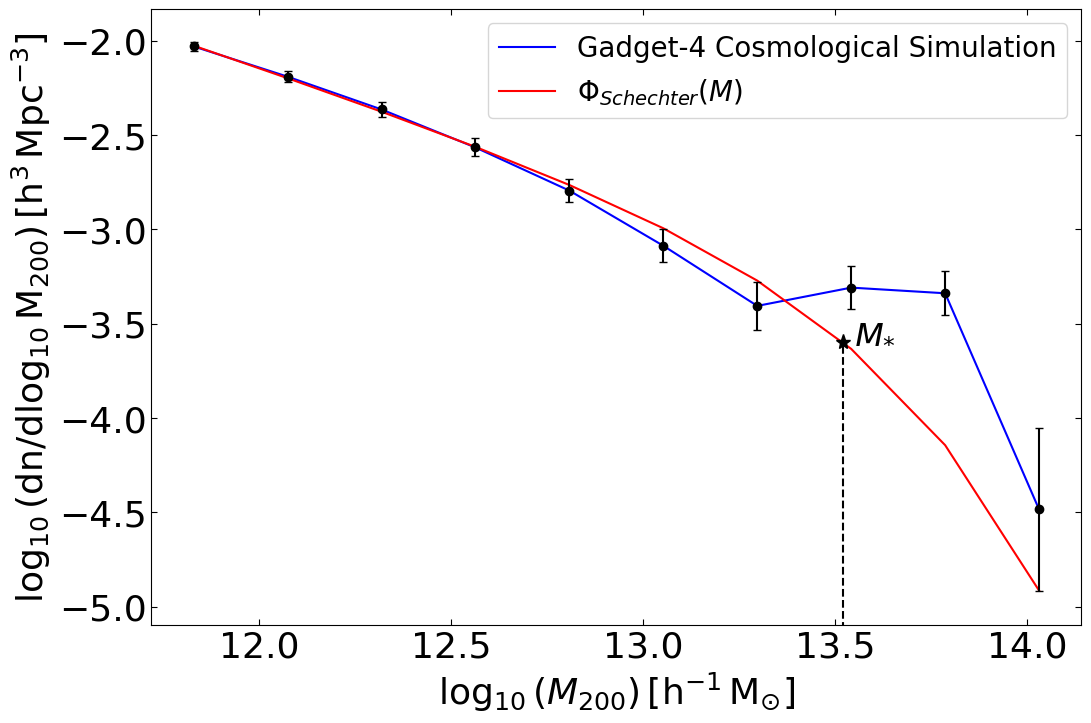

In [6]:
# Closing all plots
plt.close("all")

# Setting the constants and characteristics of the simulation
L_box = 50 # Mpc/h
vol_box = (L_box)**3 # (Mpc/h)^3
h = 0.678 
n_particles = (128)**3
mass_units = 1e10 # Msun

# Number of bins
n_bins = 10

# Importing the last snapshot as hdf5 file and extracting its data (z approx 0)
# In this last snapshot file the redshift is approximately zero (as it can be
# seen in the HEADER)
# Here we extract the M_200 mass of the DM haloes (mass contained in a R_200 radius for a density 200 times the critical density of the universe)
hdf5_file = "C:\\Users\\aleja\\astrofisica_teorica\\sim_num\\claudio_nbody\\output_ex6\\fof_subhalo_tab_002.hdf5"

with h5py.File(hdf5_file, "r") as f:
        #print("---File Information---")
        #print(list(f.keys()))
        #print(list(f["PartType1"].keys()))
        header = f["Header"].attrs
        group = f["Group"]
        #subhalo = f["Subhalo"]
        #print("")
        #print("---Group Datasets---")
        #print(list(group.keys()))
        halo_masses = np.asarray(f["Group//Group_M_Crit200"])
        #print("")
        #print("---Attributes in Header---")
        for key in header.keys():
            value = header[key]
            #print(f"{key}: {value}")
            
snapshot_file = "C:\\Users\\aleja\\astrofisica_teorica\\sim_num\\claudio_nbody\\output_ex6\\snapshot_002.hdf5"
          
# Retrieving the DM particle mass  
with h5py.File(snapshot_file, "r") as g:
    header_snap = g["Header"].attrs
    particle_mass = header_snap["MassTable"][1]
        
# Extracting the halo particle masses from the file and applying a mask for greater than zero masses
mask = halo_masses > 0
halo_masses = halo_masses[mask]
halo_masses = halo_masses[halo_masses > 100*particle_mass] # halos with more than 100 DM particles are valid
#print(f"\n Halo Masses: \n{halo_masses}") # 1e10 Msun/h

# Converting halo particle masses to physical units and in log
halo_masses = halo_masses*mass_units # Msun h^-1
#print(f"\n Halo masses in physical units: \n{halo_masses} [Msun h^-1]")

# Binning in log-space
min_mass = np.min(halo_masses)
max_mass = np.max(halo_masses)
bins = np.logspace(np.log10(min_mass), np.log10(max_mass), n_bins + 1)

# Getting the counts and edges of the histogram to plot the halo masss function
counts, edges = np.histogram(halo_masses, bins=bins)
d_log_M = np.diff(np.log10(edges))[0] # logarihmic size of bin (h^-1 Msun)

# Calculating the geometric mean to approximate a value at each bin interval 
# Remember that it is on log10
#bin_centers = 10**(0.5*(np.log10(edges[:-1]) + np.log10(edges[1:])))
bin_centers = np.sqrt(edges[:-1]*edges[1:]) #equally valid

# Mask to make only valid counts with values greater than zero
counts_mask = counts > 0 # Number of dark matter halos
counts = counts[counts_mask]
bin_centers = bin_centers[counts_mask]

# We define the halo mass function, where dn = counts/V = N/V (halo masses per volume box selected) 
# and d_log_M (log bin of masses or masses per bin interval)
# Defining the Halo Mass Function
phi = counts/(vol_box*d_log_M) # h^3 Mpc^-3 (REVISE)

# Defining the Poisson error present to plot the errorbars
log_poisson_err = 1/(np.log(10)*np.sqrt(counts)) 

# Importing the Press-Schechter function
# REMEMBER that dlog10(M) = 1/(M*ln(10)) for the way it is defined in Tinker and Press-Schechter where they use dn/dM 

# Importing the Schechter function
def schechter(mass, A, mass_star, alpha):
     log_schechter = A*np.log(10)*((mass/mass_star)**(alpha+1))*np.exp(-mass/mass_star)
     return log_schechter

#Setting the initial conditions and fitting via curve_fit
p0 = [1, 1e12, -1.5]
popt, pcov = curve_fit(schechter, bin_centers, phi, p0=p0)
print(f"\nThe optimal parameters derived from fitting for the Schechter function are: \n [A] = {popt[0]:.6f}" +  
      f"\n mass_star = {popt[1]:.3f} [Msun h^-1] \n alpha = {popt[2]:.3f}")

# Defining a schechter function instance with the derived best-fit values
schechter_plt = schechter(bin_centers, A=popt[0], mass_star=popt[1], alpha=popt[2])
schechter_star = schechter(popt[1], A=popt[0], mass_star=popt[1], alpha=popt[2]) 

# Plotting section of the snippet of code
# We are plotting the Halo Mass Function with respect to the M200 halo mass at redshift z=0
plt.figure(figsize=(12, 8))
plt.plot(np.log10(bin_centers), np.log10(phi), color="blue", label="Gadget-4 Cosmological Simulation")
plt.plot(np.log10(bin_centers), np.log10(schechter_plt), color="red", label=r"$\Phi_{Schechter}(M)$")
plt.plot(np.log10(popt[1]), np.log10(schechter_star), marker="*", color="black", markersize=11)
plt.vlines(x=np.log10(popt[1]), ymin=np.min(np.log10(schechter_plt) - 0.5), ymax=np.log10(schechter_star), linestyles="dashed", color="black")
plt.errorbar(np.log10(bin_centers), np.log10(phi), yerr=log_poisson_err, fmt="o", color="black", capsize=3)
#plt.loglog(bin_centers, phi, color="blue")
plt.tick_params(direction="in", which="major", length=4, labelsize=26, top=True, right=True)
plt.tick_params(direction="in", which="minor", length=2, labelsize=26, top=True, right=True)
#plt.xlabel(r"$M_{200} \, [\rm{h}^{-1} \, \mathrm{{M}}_{\odot}]$", fontsize=26)
#plt.ylabel(r"$\mathrm{{d}}\rm{{n}}/\mathrm{{d}}\log_{10}\rm{{M_{200}}} \, [\rm{h}^{3} \, \rm{Mpc}^{-3}]$", fontsize=26)
plt.xlabel(r"$\log_{10}(M_{200}) \, [\rm{h}^{-1} \, \mathrm{{M}}_{\odot}]$", fontsize=26)
plt.ylabel(r"$\log_{10}(\mathrm{{d}}\rm{{n}}/\mathrm{{d}}\log_{10}\rm{{M_{200}}}) \, [\rm{h}^{3} \, \rm{Mpc}^{-3}]$", fontsize=26)
#plt.text(x=8e11, y=1e-4, s="z = 0", fontsize=24, bbox=dict(boxstyle="square,pad=0.3", facecolor="white", edgecolor="black", alpha=0.8))#
plt.ylim(bottom=-5.1)
plt.text(x=13.55, y=-3.6, s=r"$M_{*}$", fontsize=24)
plt.legend(prop={'size': 20})
plt.savefig("halo_mass_function_new.pdf", dpi=300)
plt.show()